In [14]:
!nvidia-smi

Thu Feb 26 00:16:43 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.211.01             Driver Version: 570.211.01     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4090        Off |   00000000:01:00.0  On |                  Off |
|  0%   35C    P8             16W /  450W |    5565MiB /  24564MiB |      1%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [15]:
%pip install torch torchvision
%pip install nvidia-ml-py
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [16]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))


True
NVIDIA GeForce RTX 4090


In [17]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.ToTensor(),
])


train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform,
)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

In [19]:
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd.profiler import record_function

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3)
        self.conv2 = nn.Conv2d(32, 64, 3)
        self.fc1 = nn.Linear(64 * 5 * 5, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):

        with record_function("layer_conv1"):
            x = F.relu(self.conv1(x))
            x = F.max_pool2d(x, 2)

        with record_function("layer_conv2"):
            x = F.relu(self.conv2(x))
            x = F.max_pool2d(x, 2)

        with record_function("layer_fc1"):
            x = x.view(x.size(0), -1)
            x = F.relu(self.fc1(x))
        
        with record_function("layer_fc2"):
            x = self.fc2(x)

        return x

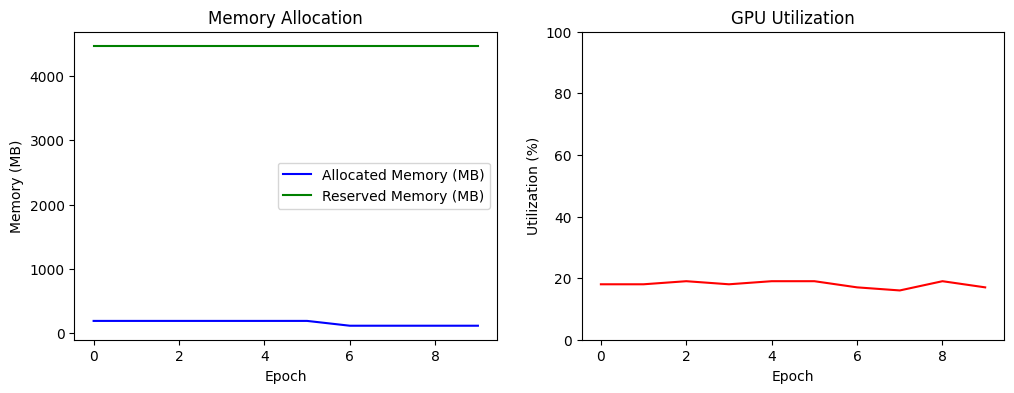

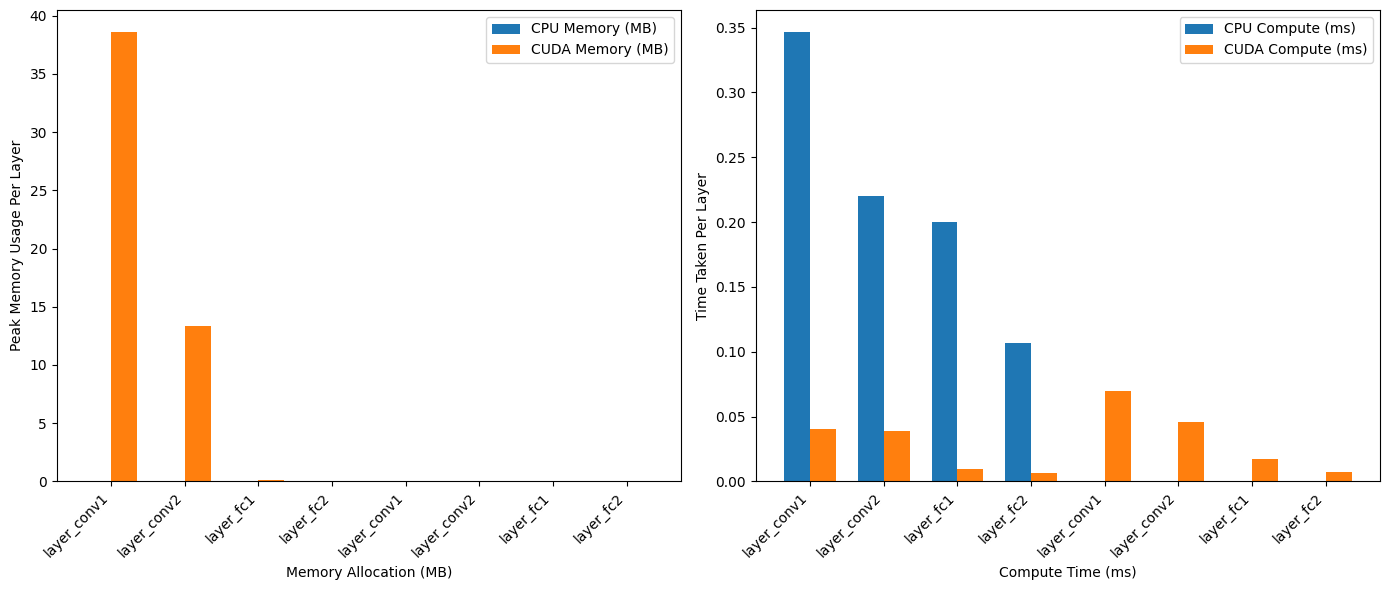

In [23]:
import time
import pynvml
import matplotlib.pyplot as plt
from IPython.display import clear_output
from torch.profiler import profile, ProfilerActivity
import numpy as np

device = "cuda"
pynvml.nvmlInit()
handle = pynvml.nvmlDeviceGetHandleByIndex(0)

model = SimpleCNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

start = time.time()

allocated_history = []
reserved_history = []
utilization_history = []

for epoch in range(10):

    if epoch == 5:
        profiler_results = []

        def trace_handler(p):
            profiler_results.append(p.key_averages())

        with profile(
            activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA],
            schedule=torch.profiler.schedule(wait=1, warmup=1, active=2),
            on_trace_ready=trace_handler,
            record_shapes=True,
            profile_memory=True,
            with_stack=True,
        ) as prof:
            for batch_idx, (data, target) in enumerate(train_loader):
                if batch_idx >= 4:
                    break
                data, target = data.to(device), target.to(device)
                optimizer.zero_grad()
                output = model(data)
                loss = criterion(output, target)
                loss.backward()
                optimizer.step()

                allocated_mb = torch.cuda.memory_allocated() / (1024 ** 2)
                reserved_mb = torch.cuda.memory_reserved() / (1024 ** 2)

                utilization_percent = pynvml.nvmlDeviceGetUtilizationRates(handle).gpu

                prof.step()
    else:
        for data, target in train_loader:
            data, target = data.to(device), target.to(device)
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()

            allocated_mb = torch.cuda.memory_allocated() / (1024 ** 2)
            reserved_mb = torch.cuda.memory_reserved() / (1024 ** 2)

            utilization_percent = pynvml.nvmlDeviceGetUtilizationRates(handle).gpu

    allocated_history.append(allocated_mb)
    reserved_history.append(reserved_mb)
    utilization_history.append(utilization_percent)

    if epoch % 1 == 0:
        clear_output(wait=True)

        fig, (ax1, ax2) = plt.subplots(1,2,figsize=(12,4))
        
        ax1.plot(allocated_history, label='Allocated Memory (MB)', color='blue')
        ax1.plot(reserved_history, label='Reserved Memory (MB)', color='green')
        ax1.set_title('Memory Allocation')  
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Memory (MB)')
        ax1.legend()

        ax2.plot(utilization_history, label='GPU Utilization (%)', color='red')
        ax2.set_title('GPU Utilization')
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('Utilization (%)')
        ax2.set_ylim(0, 100)
        
        plt.show()

end = time.time()

layer_names = []
layer_cuda_memory_mb = []
layer_cpu_memory_mb = []
layer_cuda_compute_ms = []
layer_cpu_compute_ms = []

for event in profiler_results[-1]:
    if "layer_" in event.key:
        layer_names.append(event.key)

        cuda_mem_mb = event.device_memory_usage / (1024 ** 2)
        layer_cuda_memory_mb.append(cuda_mem_mb)

        cpu_mem_mb = event.cpu_memory_usage / (1024 ** 2)
        layer_cpu_memory_mb.append(cpu_mem_mb)

        cuda_compute_ms = event.device_time_total / 1000
        layer_cuda_compute_ms.append(cuda_compute_ms)

        cpu_compute_ms = event.cpu_time_total / 1000
        layer_cpu_compute_ms.append(cpu_compute_ms)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

x = np.arange(len(layer_names))
width = 0.35

rects1 = ax1.bar(x-width/2, layer_cpu_memory_mb, width, label='CPU Memory (MB)')
rects2 = ax1.bar(x+width/2, layer_cuda_memory_mb, width, label='CUDA Memory (MB)')

ax1.set_xlabel('Memory Allocation (MB)')
ax1.set_ylabel('Peak Memory Usage Per Layer')
ax1.set_xticks(x)
ax1.set_xticklabels(layer_names, rotation=45, ha='right')
ax1.legend()

rects3 = ax2.bar(x-width/2, layer_cpu_compute_ms, width, label='CPU Compute (ms)')
rects4 = ax2.bar(x+width/2, layer_cuda_compute_ms, width, label='CUDA Compute (ms)')

ax2.set_xlabel('Compute Time (ms)')
ax2.set_ylabel('Time Taken Per Layer')
ax2.set_xticks(x)
ax2.set_xticklabels(layer_names, rotation=45, ha='right')
ax2.legend()

fig.tight_layout()
plt.show()










        


In [ ]:
import time
from torch.utils.tensorboard import SummaryWriter
import pynvml
import matplotlib.pyplot as plt
from IPython.display import clear_output

def train(device):
    model = SimpleCNN().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    start = time.time()
    writer = SummaryWriter(f'runs/mnist_cnn_{device}')

    for epoch in range(2):
        for data, target in train_loader:
            data, target = data.to(device), target.to(device)
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()

            if epoch % 100 == 0:
                writer.add_scalar('loss', loss.item(), epoch * len(train_loader))

    writer.close()
    end = time.time()
    return end - start

In [24]:
cpu_time = train("cpu")
gpu_time = train("cuda")

print(f"CPU training time: {cpu_time:.2f} seconds")
print(f"GPU training time: {gpu_time:.2f} seconds")

CPU training time: 13.99 seconds
GPU training time: 4.15 seconds


In [13]:
%pip install tensorboard
%load_ext tensorboard
%tensorboard --logdir runs -port 6006

Note: you may need to restart the kernel to use updated packages.
The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


ERROR: Failed to launch TensorBoard (exited with 2).
Contents of stderr:
TensorFlow installation not found - running with reduced feature set.
usage: tensorboard [-h] [--helpfull] [--logdir PATH] [--logdir_spec PATH_SPEC]
                   [--host ADDR] [--bind_all] [--port PORT]
                   [--reuse_port BOOL] [--load_fast {false,auto,true}]
                   [--extra_data_server_flags EXTRA_DATA_SERVER_FLAGS]
                   [--grpc_creds_type {local,ssl,ssl_dev}]
                   [--grpc_data_provider PORT] [--purge_orphaned_data BOOL]
                   [--db URI] [--db_import] [--inspect] [--version_tb]
                   [--tag TAG] [--event_file PATH] [--path_prefix PATH]
                   [--window_title TEXT] [--max_reload_threads COUNT]
                   [--reload_interval SECONDS] [--reload_task TYPE]
                   [--reload_multifile BOOL]
                   [--reload_multifile_inactive_secs SECONDS]
                   [--generic_data TYPE]
            

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.datasets as datasets
import torchvision.transforms as transforms
import torchvision.models as models
from torch.profiler import profile, ProfilerActivity, tensorboard_trace_handler
import datetime


device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])
train_set = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
cifar_loader = DataLoader(train_set, batch_size=128, shuffle=True)

model = models.resnet18().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

log_dir = "runs/pytorch_profiler_" + datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

with profile(
    activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA],
    schedule=torch.profiler.schedule(wait=1, warmup=1, active=2),
    on_trace_ready=tensorboard_trace_handler(log_dir),
    record_shapes=True,
    profile_memory=True,
    with_stack=True,
) as prof:
    for i, (inputs, labels) in enumerate(train_loader):
        if i >= 4:
            break

        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        prof.step()

print("\n" + "="*30)
print(" DETAILED MEMORY PROFILE")
print("="*30)

print(prof.key_averages().table(
    sort_by="self_cpu_memory_usage", 
    row_limit=10,
    header="PyTorch Memory Profile"
))

if torch.cuda.is_available():
    print(f"\nMax GPU memory allocated: {torch.cuda.max_memory_allocated() / 1024**2:.2f} MB")
    print(f"Max GPU memory reserved: {torch.cuda.max_memory_reserved() / 1024**2:.2f} MB")




Using device: cuda


/home/joel/Desktop/CS-HW/venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")
[W225 23:57:58.140136349 CPUAllocator.cpp:245] Memory block of unknown size was allocated before the profiling started, profiler results will not include the deallocation event



 DETAILED MEMORY PROFILE
PyTorch Memory Profile
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                    aten::empty_strided         1.12%       4.021ms         1.12%       4.021ms       3.904us       0.000us         0.00%       0.000us       0.000us     2

In [11]:
%pip install tensorboard
%tensorboard --logdir runs

Note: you may need to restart the kernel to use updated packages.


UsageError: Line magic function `%tensorboard` not found.
